## Imports

In [1]:
import os                    
import matplotlib           
import matplotlib.pyplot as plt
import numpy as np            
import astropy.io.fits       
import astropy.coordinates   
import fitsio               
import sdss_access          
from astropy.coordinates import SkyCoord
import astropy.units as u

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.size'] = 14

url_root = 'https://data.sdss.org/sas'
local_root = os.getenv('SAS_BASE_DIR')

sdss_path = sdss_access.path.Path(release='dr19', verbose=True)

## Allspec

In [2]:
sdss_path = sdss_access.path.Path(release='dr19', verbose=True)
access = sdss_access.Access(release='dr19', verbose=True)

allspec_file = sdss_path.full('allspec', vers='1.0.1', release='dr19')

if not sdss_path.exists('', full=allspec_file):
    access.remote()
    access.add('allspec', vers='1.0.1', release='dr19')
    access.set_stream()
    access.commit()

allspec_hdus = astropy.io.fits.open(allspec_file)
allspec = np.array(allspec_hdus[1].data)

## Unique objects

In [3]:
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

isfinite = np.isfinite(unique_ra) & np.isfinite(unique_dec)
unique_indx = unique_indx[isfinite]
unique_ra = unique_ra[isfinite]
unique_dec = unique_dec[isfinite]
unique_coords = astropy.coordinates.SkyCoord(unique_ra, unique_dec, unit='deg', frame='icrs')

indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords)
sep = sep.value   # get separation from each object and target location in units of degrees


## Fries's Quasar

In [4]:
# Fries's quasar coordinates
ra_fries = 212.67189
dec_fries = 53.313609

target = SkyCoord(ra_fries*u.deg, dec_fries*u.deg) # target location

# Extract unique objects from allspec (all lowercase here)
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

mask = np.isfinite(unique_ra) & np.isfinite(unique_dec) #np.isfinite from APPM2360 project 2
# np.isfinite https://medium.com/@whyamit404/understanding-numpy-isfinite-with-examples-7305ff609ce9 

# update unique_ra and unique_dec with only usable numbers
unique_ra = unique_ra[mask]
unique_dec = unique_dec[mask]
unique_sdss_id = unique_sdss_id[mask]

# indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords) except I don't wnat to center them I want the exact target to match my unique_coord 
unique_coords = SkyCoord(unique_ra, unique_dec, unit='deg') # this is where units='deg' comes in
indx, sep, _ = target.match_to_catalog_sky(unique_coords) # I use "_" becasue the variable is temporary and mostly a placeholder
#Find an ID for this quasar so I don't have to rmember Ra/Dec
fries_sdss_id = unique_sdss_id[indx] # Maybe we can use this in Sky server?
print("Fries's SDSS-V ID:", fries_sdss_id)
print("Angular separation (arcsec):", sep.to(u.arcsec).value)

Fries's SDSS-V ID: 62243506
Angular separation (arcsec): [0.23233907]


In [5]:
# check how mny visits this quasar has (hopefully a lot)
fries_rows = allspec[allspec['sdss_id'] == fries_sdss_id]
# If I print the length of rows for this quasar it should tell me how many times it is in the d19 allspec dataset which is really the number of epochs it has.
print("Number of epochs:", len(fries_rows))

Number of epochs: 280


The Spectra

In [6]:
# Now that we know there are multiple visits we can pull the data from those visits to start analyzing the spectra
spectra = []

for row in fries_rows:
    sas_url = row['sas_url'].decode()
    local_path = sas_url.replace(url_root, local_root)

    if not os.path.exists(local_path):
        access.remote()
        access.add(row['sas_url']) #line of error?
        access.set_stream()
        access.commit()

    # open the FITS file
    hdul = astropy.io.fits.open(local_path)
    data = hdul[1].data

    wavelength = 10**data['loglam']
    flux = data['flux']
    mjd = row['mjd']

    spectra.append({
        "wavelength": wavelength,
        "flux": flux,
        "mjd": mjd
    })

## Loading spAll

In [11]:
# Allspec does not have z specs so I should load in spall
# Load spAll Like in lab04 and others
spall_file = sdss_path.full('spAll', run2d='v6_1_3')

if not sdss_path.exists('', full=spall_file):
    access.remote()
    access.add('spAll', run2d='v6_1_3')
    access.set_stream()
    access.commit()

print("spAll file:", spall_file)

# Not alspec anymore -> spall uses all CAPS!
spall_columns = [
    'SDSS_ID', 'CARTON_TO_TARGET_PK', 'MJD', 'CLASS', 'SUBCLASS',
    'Z', 'ZWARNING', 'SN_MEDIAN_ALL', 'PSFMAG', 'SPEC_FILE',
    'HEALPIX_PATH', 'OBJTYPE'
]

spall_rows_fries = fitsio.read(spall_file, columns=spall_columns)
z_fries = np.nanmedian(spall_rows_fries['Z'])
print("Fries median redshift:", z_fries)

spAll file: /home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spAll-v6_1_3.fits.gz
Fries median redshift: 0.17697567


## Rest Wavelengths and Observed Wavelengths

In [13]:
## useful atomic emission lines in quasar spectra (units of Angstrom, same as our spectra): ##
    # (from day 1 nb)
rest_lambda = {
    "OVI":     1034.0,
    "Lyalpha": 1216.0,
    "CIV":     1549.0,
    "CIII":    1908.0,
    "MGII":    2799.0,
    "Hbeta":   4862.0,
    "Hgamma":  4361.0,
    "Halpha":  6564.0
}

# H Beta
lambda_rest_h_beta = rest_lambda["Hbeta"]
# H alpha
lambda_rest_h_alpha = rest_lambda["Halpha"]

# Centers
center_hb_fries = lambda_rest_h_beta * (1+z_fries)
center_ha_fries = lambda_rest_h_alpha * (1+z_fries)

print(f'Fries Hβ observed center: {center_hb_fries:.2f} Å')
print(f'Fries Hα observed center: {center_ha_fries:.2f} Å')

Fries Hβ observed center: 5722.46 Å
Fries Hα observed center: 7725.67 Å


## Useful Functions

In [14]:
def continuum_flux(wl, fl, lam_min, lam_max):
    mask = (wl > lam_min) & (wl < lam_max)
    return np.nanmedian(fl[mask])

In [31]:
def line_flux(wl, fl, center, width=40):
    lam_min = center - width
    lam_max = center + width

    mask = (wl > lam_min) & (wl < lam_max)

    # continuum from edges
    cont_mask = ((wl > lam_min) & (wl < lam_min+10)) | \
                ((wl < lam_max) & (wl > lam_max-10))
    cont = np.nanmedian(fl[cont_mask])

    return np.trapz(fl[mask] - cont, wl[mask])

## Hβ Fries

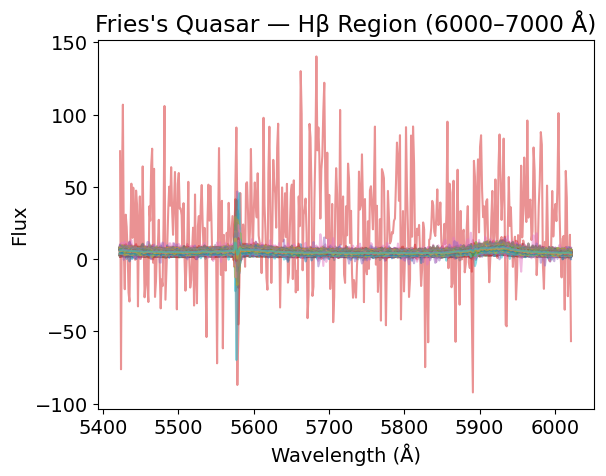

In [17]:
matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_beta = (wl > center_hb_fries - 300) & (wl < center_hb_fries + 300)
    plt.plot(wl[mask_beta], fl[mask_beta], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Fries's Quasar — Hβ Region (6000–7000 Å)")
plt.show();

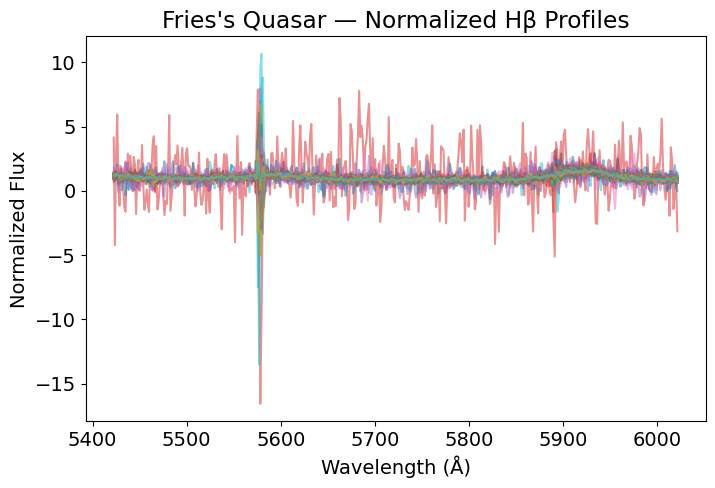

In [21]:
plt.figure(figsize=(8,5))
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_beta = (wl > center_hb_fries - 300) & (wl < center_hb_fries + 300)
    wl_zoom   = wl[mask_beta]
    fl_zoom   = fl[mask_beta]

    cont = continuum_flux(wl_zoom, fl_zoom, center_hb_fries - 250, center_hb_fries - 150)
    plt.plot(wl_zoom, fl_zoom / cont, alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Fries's Quasar — Normalized Hβ Profiles")
plt.show();

## Hα Fries

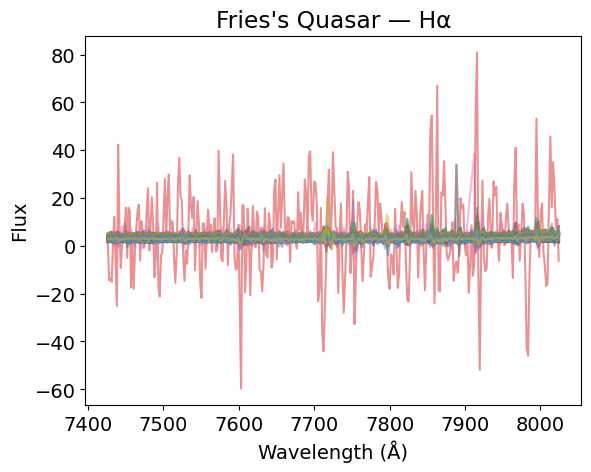

In [28]:
matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_alpha = (wl > center_ha_fries - 300) & (wl < center_ha_fries + 300)
    plt.plot(wl[mask_alpha], fl[mask_alpha], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Fries's Quasar — Hα")
plt.show();

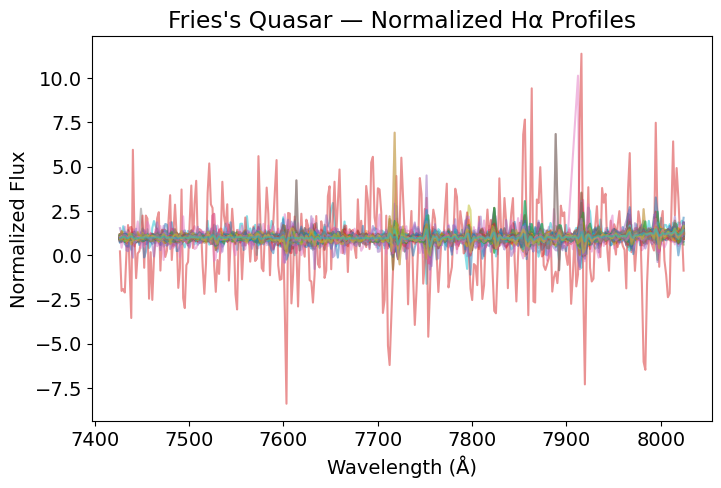

In [29]:
plt.figure(figsize=(8,5))
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_alpha = (wl > center_ha_fries - 300) & (wl < center_ha_fries + 300)
    wl_zoom    = wl[mask_alpha]
    fl_zoom    = fl[mask_alpha]

    cont = continuum_flux(wl_zoom, fl_zoom,
                          center_ha_fries - 250,
                          center_ha_fries - 150)
    plt.plot(wl_zoom, fl_zoom / cont, alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Fries's Quasar — Normalized Hα Profiles")
plt.show();

## Continuum Light Curves

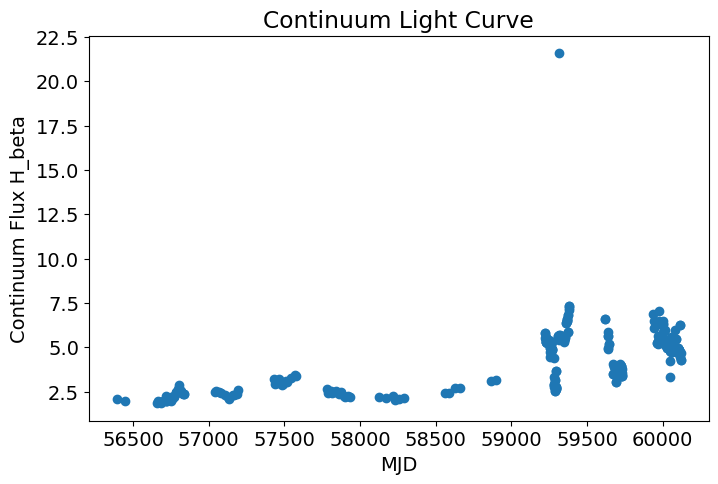

In [27]:
cont_times_fries = []
cont_values_fries = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, center_hb_fries - 250, center_hb_fries + 150)  # from previous cells
    cont_times_fries.append(mjd)
    cont_values_fries.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_fries, cont_values_fries)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux H_beta")
plt.title("Continuum Light Curve")
plt.show();

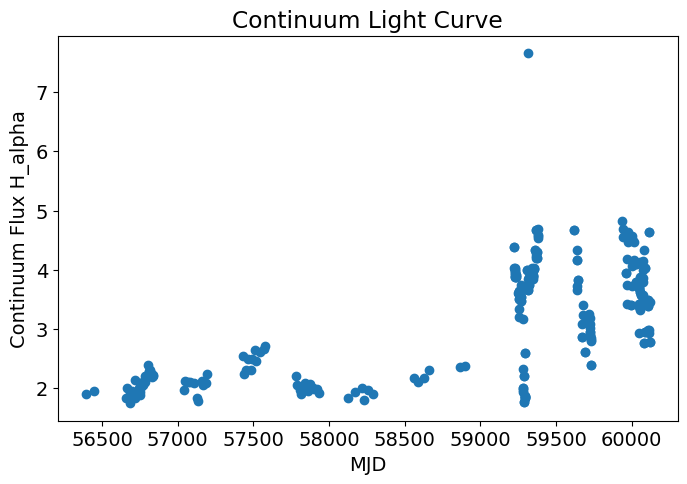

In [45]:
cont_times_fries = []
cont_values_fries = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, center_ha_fries - 250, center_ha_fries + 150)  # from previous cells
    cont_times_fries.append(mjd)
    cont_values_fries.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_fries, cont_values_fries)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux H_alpha")
plt.title("Continuum Light Curve")
plt.show();

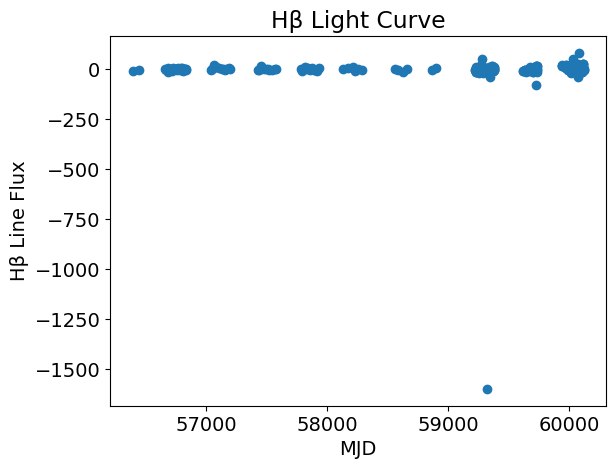

In [47]:
hb_times_fries = []
hb_values_fries = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f_line = line_flux(wl, fl, center_hb_fries, width=40)
    hb_times_fries.append(mjd)
    hb_values_fries.append(f_line)
plt.scatter(hb_times_fries, hb_values_fries)
plt.xlabel("MJD")
plt.ylabel("Hβ Line Flux")
plt.title("Hβ Light Curve")
plt.show();

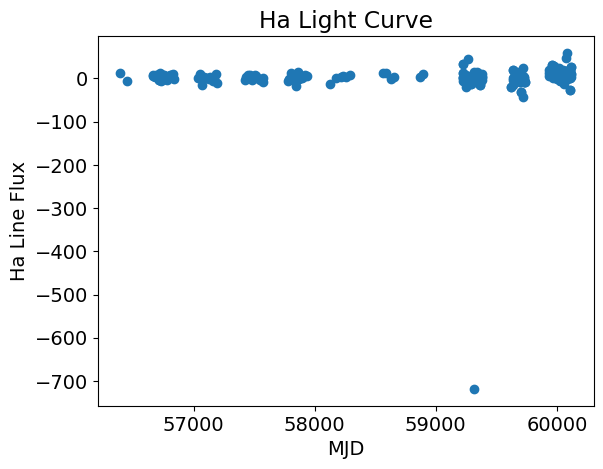

In [48]:
ha_times_fries = []
ha_values_fries = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f_line = line_flux(wl, fl, center_ha_fries, width=40)
    ha_times_fries.append(mjd)
    ha_values_fries.append(f_line)
plt.scatter(ha_times_fries, ha_values_fries)
plt.xlabel("MJD")
plt.ylabel("Ha Line Flux")
plt.title("Ha Light Curve")
plt.show();

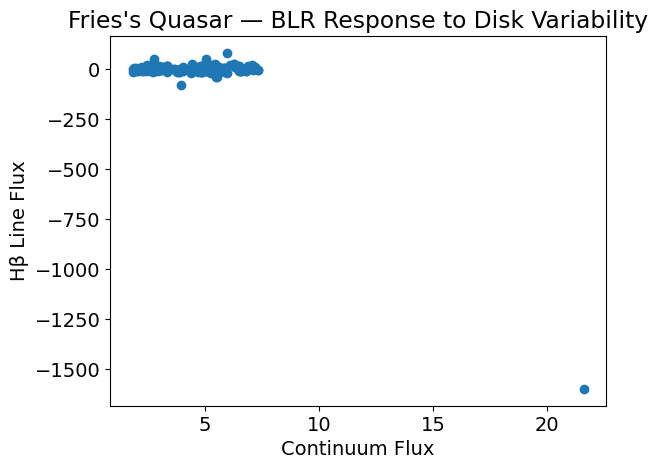

In [39]:
plt.scatter(cont_values_fries, hb_values_fries)
plt.xlabel("Continuum Flux")
plt.ylabel("Hβ Line Flux")
plt.title("Fries's Quasar — BLR Response to Disk Variability")
plt.show();

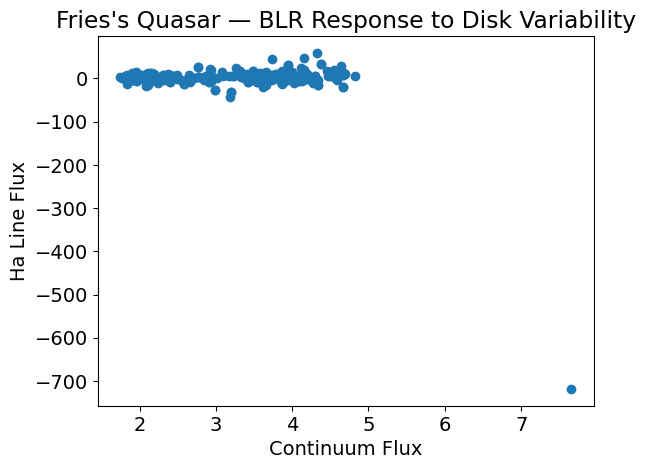

In [49]:
plt.scatter(cont_values_fries, ha_values_fries)
plt.xlabel("Continuum Flux")
plt.ylabel("Ha Line Flux")
plt.title("Fries's Quasar — BLR Response to Disk Variability")
plt.show();

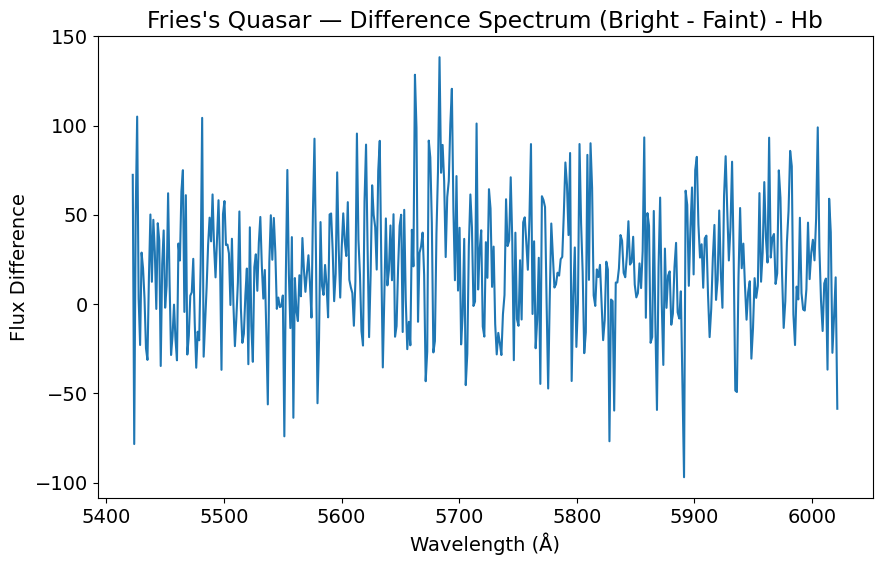

In [51]:
i_bright = np.argmax(cont_values_fries)
i_faint  = np.argmin(cont_values_fries)

wl_b = spectra[i_bright]["wavelength"]
fl_b = spectra[i_bright]["flux"]

wl_f = spectra[i_faint]["wavelength"]
fl_f = spectra[i_faint]["flux"]

fl_f_interp = np.interp(wl_b, wl_f, fl_f)

mask_diff = (wl_b > center_hb_fries - 300) & (wl_b < center_hb_fries + 300)

plt.figure(figsize=(10,6))
plt.plot(wl_b[mask_diff], fl_b[mask_diff] - fl_f_interp[mask_diff])
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux Difference")
plt.title("Fries's Quasar — Difference Spectrum (Bright - Faint) - Hb")
plt.show();

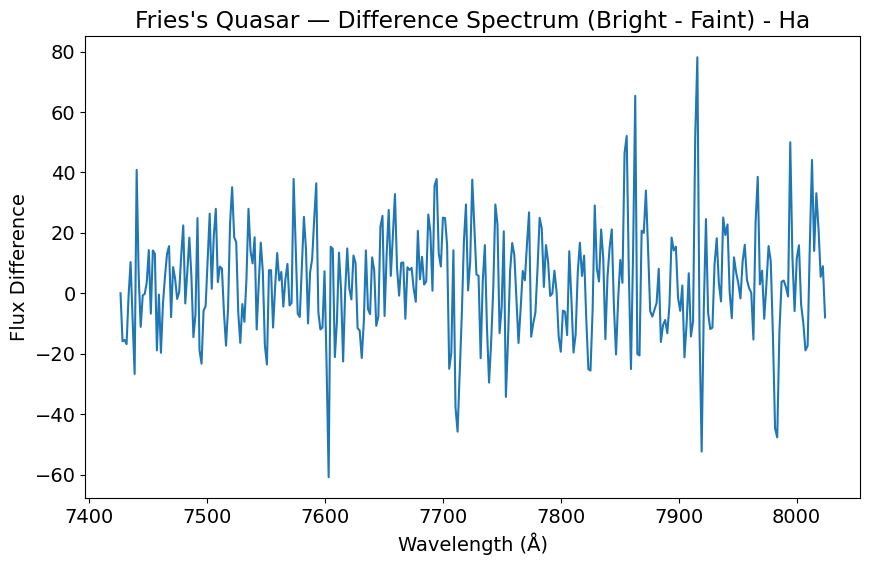

In [52]:
i_bright = np.argmax(cont_values_fries)
i_faint  = np.argmin(cont_values_fries)

wl_a = spectra[i_bright]["wavelength"]
fl_a = spectra[i_bright]["flux"]

wl_f = spectra[i_faint]["wavelength"]
fl_f = spectra[i_faint]["flux"]

fl_f_interp = np.interp(wl_a, wl_f, fl_f)

mask_diff = (wl_a > center_ha_fries - 300) & (wl_a < center_ha_fries + 300)

plt.figure(figsize=(10,6))
plt.plot(wl_a[mask_diff], fl_a[mask_diff] - fl_f_interp[mask_diff])
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux Difference")
plt.title("Fries's Quasar — Difference Spectrum (Bright - Faint) - Ha")
plt.show();

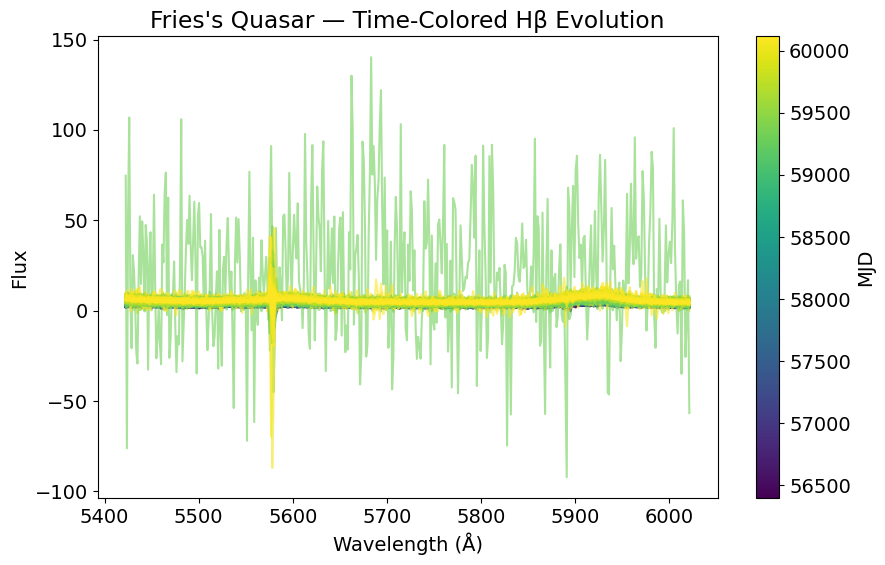

In [44]:
fig, ax = plt.subplots(figsize=(10,6))

mjds_fries = np.array([s["mjd"] for s in spectra])
norm = plt.Normalize(mjds_fries.min(), mjds_fries.max())
cmap = plt.cm.viridis

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mask_tc = (wl > center_hb_fries - 300) & (wl < center_hb_fries + 300)
    ax.plot(wl[mask_tc], fl[mask_tc], color=cmap(norm(s["mjd"])), alpha=0.6)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="MJD")

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Flux")
ax.set_title("Fries's Quasar — Time-Colored Hβ Evolution")
plt.show();

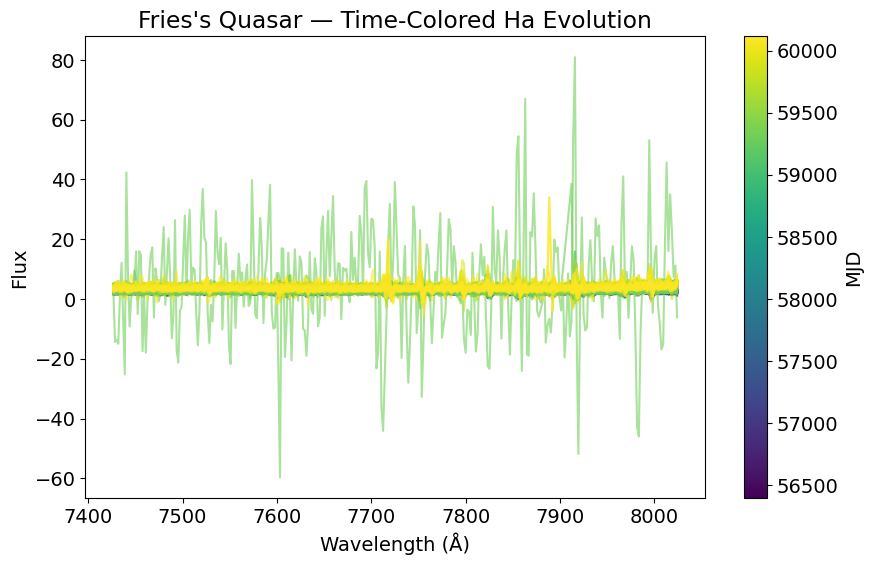

In [53]:
fig, ax = plt.subplots(figsize=(10,6))

mjds_fries = np.array([s["mjd"] for s in spectra])
norm = plt.Normalize(mjds_fries.min(), mjds_fries.max())
cmap = plt.cm.viridis

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mask_tc = (wl > center_ha_fries - 300) & (wl < center_ha_fries + 300)
    ax.plot(wl[mask_tc], fl[mask_tc], color=cmap(norm(s["mjd"])), alpha=0.6)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="MJD")

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Flux")
ax.set_title("Fries's Quasar — Time-Colored Ha Evolution")
plt.show();

## Jason's Quasar

In [55]:
# Jason's quasar coordinates
ra_jason = 213.351149549
dec_jason = 53.090819798

target = SkyCoord(ra_jason*u.deg, dec_jason*u.deg) # target location

# Extract unique objects from allspec (all lowercase here)
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

mask = np.isfinite(unique_ra) & np.isfinite(unique_dec) #np.isfinite from APPM2360 project 2
# np.isfinite https://medium.com/@whyamit404/understanding-numpy-isfinite-with-examples-7305ff609ce9 

# update unique_ra and unique_dec with only usable numbers
unique_ra = unique_ra[mask]
unique_dec = unique_dec[mask]
unique_sdss_id = unique_sdss_id[mask]

# indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords) except I don't wnat to center them I want the exact target to match my unique_coord 
unique_coords = SkyCoord(unique_ra, unique_dec, unit='deg') # this is where units='deg' comes in
indx, sep, _ = target.match_to_catalog_sky(unique_coords) # I use "_" becasue the variable is temporary and mostly a placeholder
#Find an ID for this quasar so I don't have to rmember Ra/Dec
jason_sdss_id = unique_sdss_id[indx] # Maybe we can use this in Sky server?
print("Jasons's SDSS-V ID:", jason_sdss_id)
print("Angular separation (arcsec):", sep.to(u.arcsec).value)

Jasons's SDSS-V ID: 62239511
Angular separation (arcsec): [0.07615622]


In [56]:
# check how mny visits this quasar has (hopefully a lot)
jason_rows = allspec[allspec['sdss_id'] == jason_sdss_id]
# If I print the length of rows for this quasar it should tell me how many times it is in the d19 allspec dataset which is really the number of epochs it has.
print("Number of epochs:", len(jason_rows))

Number of epochs: 175


In [57]:
# Now that we know there are multiple visits we can pull the data from those visits to start analyzing the spectra
spectra = []

for row in jason_rows:
    sas_url = row['sas_url'].decode()
    local_path = sas_url.replace(url_root, local_root)

    if not os.path.exists(local_path):
        access.remote()
        access.add(row['sas_url']) #line of error?
        access.set_stream()
        access.commit()

    # open the FITS file
    hdul = astropy.io.fits.open(local_path)
    data = hdul[1].data

    wavelength = 10**data['loglam']
    flux = data['flux']
    mjd = row['mjd']

    spectra.append({
        "wavelength": wavelength,
        "flux": flux,
        "mjd": mjd
    })

In [58]:
# Allspec does not have z specs so I should load in spall
# Load spAll Like in lab04 and others
spall_file = sdss_path.full('spAll', run2d='v6_1_3')

if not sdss_path.exists('', full=spall_file):
    access.remote()
    access.add('spAll', run2d='v6_1_3')
    access.set_stream()
    access.commit()

print("spAll file:", spall_file)

# Not alspec anymore -> spall uses all CAPS!
spall_columns = [
    'SDSS_ID', 'CARTON_TO_TARGET_PK', 'MJD', 'CLASS', 'SUBCLASS',
    'Z', 'ZWARNING', 'SN_MEDIAN_ALL', 'PSFMAG', 'SPEC_FILE',
    'HEALPIX_PATH', 'OBJTYPE'
]

spall_rows_jason = fitsio.read(spall_file, columns=spall_columns)
z_jason = np.nanmedian(spall_rows_jason['Z'])
print("Jason's median redshift:", z_jason)

spAll file: /home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spAll-v6_1_3.fits.gz
Jason's median redshift: 0.17697567


In [59]:
# H Beta
lambda_rest_h_beta = rest_lambda["Hbeta"]
# H alpha
lambda_rest_h_alpha = rest_lambda["Halpha"]

# Centers
center_hb_jason = lambda_rest_h_beta * (1+z_jason)
center_ha_jason = lambda_rest_h_alpha * (1+z_jason)

print(f'Jason Hβ observed center: {center_hb_jason:.2f} Å')
print(f'Jason Hα observed center: {center_ha_jason:.2f} Å')

Jason Hβ observed center: 5722.46 Å
Jason Hα observed center: 7725.67 Å


In [60]:
def continuum_flux(wl, fl, lam_min, lam_max):
    mask = (wl > lam_min) & (wl < lam_max)
    return np.nanmedian(fl[mask])

In [61]:
def line_flux(wl, fl, center, width=40):
    lam_min = center - width
    lam_max = center + width

    mask = (wl > lam_min) & (wl < lam_max)

    # continuum from edges
    cont_mask = ((wl > lam_min) & (wl < lam_min+10)) | \
                ((wl < lam_max) & (wl > lam_max-10))
    cont = np.nanmedian(fl[cont_mask])

    return np.trapz(fl[mask] - cont, wl[mask])

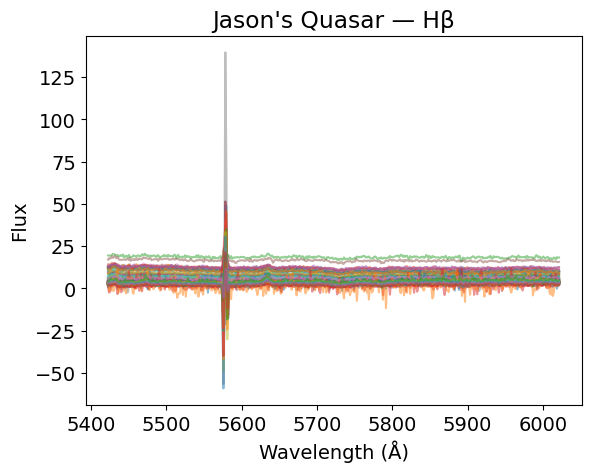

In [62]:
matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_beta = (wl > center_hb_jason - 300) & (wl < center_hb_jason + 300)
    plt.plot(wl[mask_beta], fl[mask_beta], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Jason's Quasar — Hβ")
plt.show();

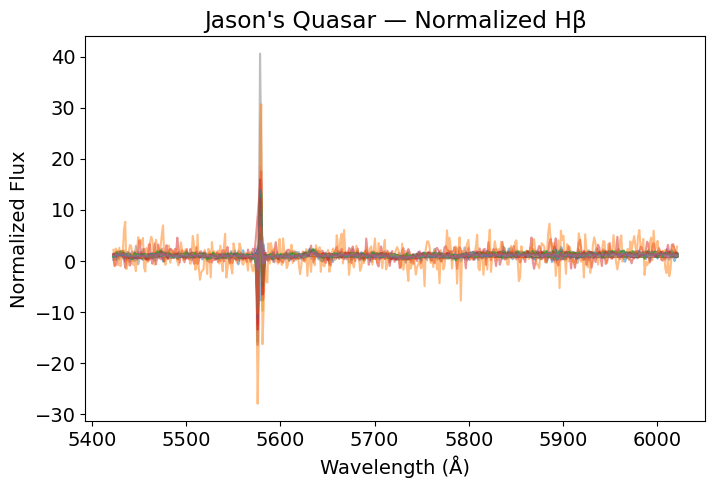

In [63]:
plt.figure(figsize=(8,5))
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_beta = (wl > center_hb_jason - 300) & (wl < center_hb_jason + 300)
    wl_zoom   = wl[mask_beta]
    fl_zoom   = fl[mask_beta]

    cont = continuum_flux(wl_zoom, fl_zoom, center_hb_jason - 250, center_hb_jason - 150)
    plt.plot(wl_zoom, fl_zoom / cont, alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Jason's Quasar — Normalized Hβ")
plt.show();

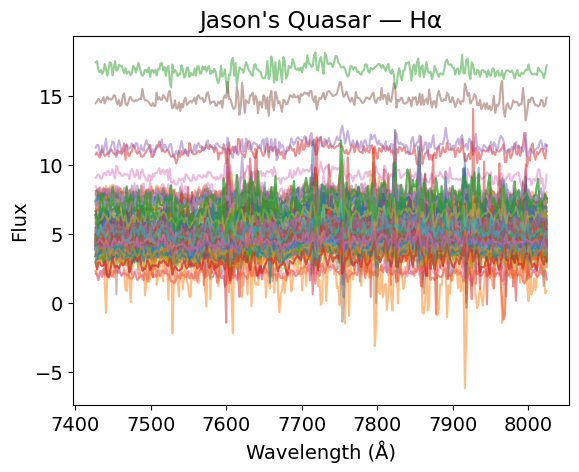

In [64]:
matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_alpha = (wl > center_ha_jason - 300) & (wl < center_ha_jason + 300)
    plt.plot(wl[mask_alpha], fl[mask_alpha], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Jason's Quasar — Hα")
plt.show();

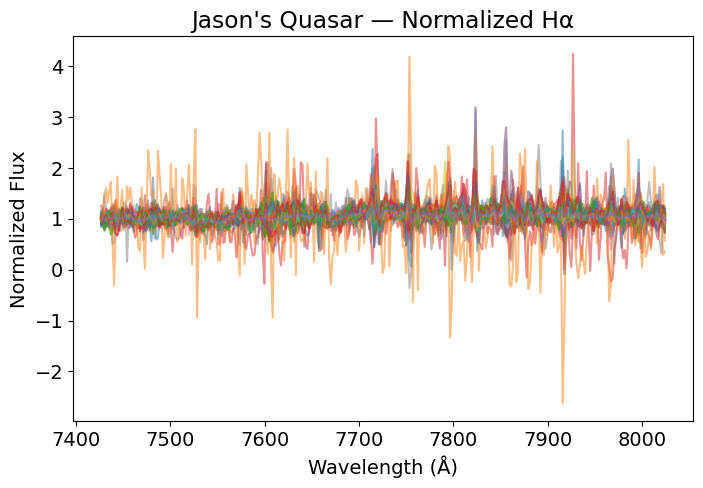

In [65]:
plt.figure(figsize=(8,5))
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_alpha = (wl > center_ha_jason - 300) & (wl < center_ha_jason + 300)
    wl_zoom    = wl[mask_alpha]
    fl_zoom    = fl[mask_alpha]

    cont = continuum_flux(wl_zoom, fl_zoom,center_ha_jason - 250,center_ha_jason - 150)
    plt.plot(wl_zoom, fl_zoom / cont, alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Jason's Quasar — Normalized Hα")
plt.show();

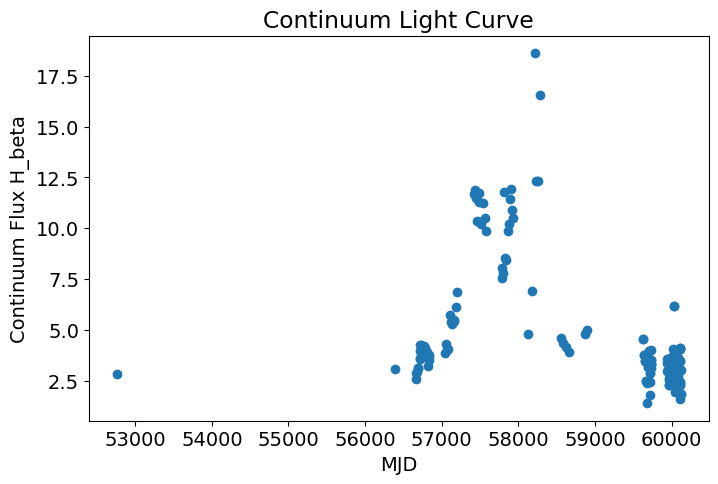

In [66]:
cont_times_jason = []
cont_values_jason = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, center_hb_jason - 250, center_hb_jason + 150)
    cont_times_jason.append(mjd)
    cont_values_jason.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_jason, cont_values_jason)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux H_beta")
plt.title("Continuum Light Curve")
plt.show();

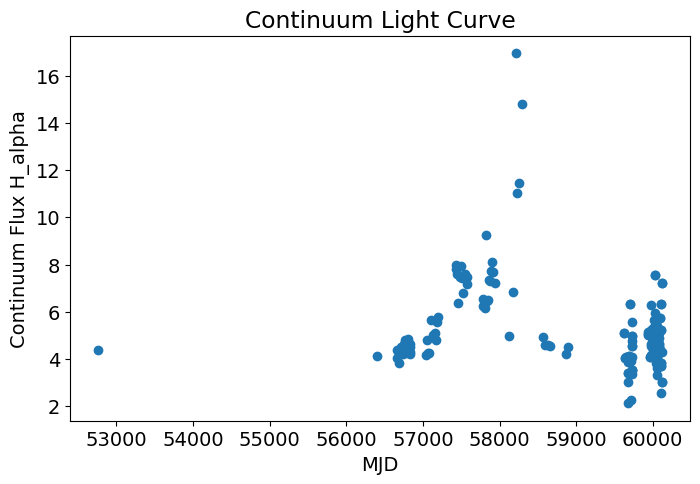

In [67]:
cont_times_jason = []
cont_values_jason = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, center_ha_jason - 250, center_ha_jason + 150)
    cont_times_jason.append(mjd)
    cont_values_jason.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_jason, cont_values_jason)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux H_alpha")
plt.title("Continuum Light Curve")
plt.show();

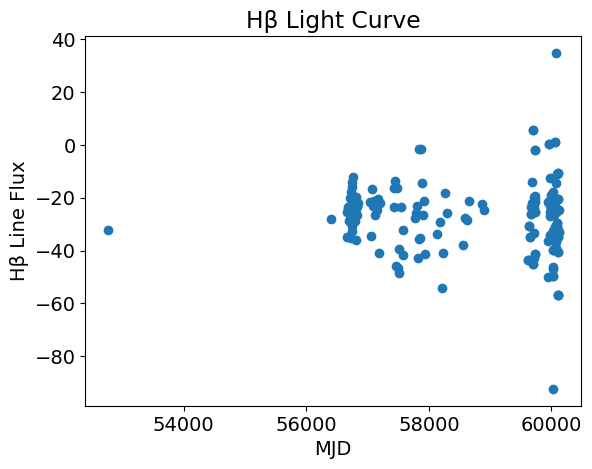

In [68]:
hb_times_jason = []
hb_values_jason = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f_line = line_flux(wl, fl, center_hb_jason, width=40)
    hb_times_jason.append(mjd)
    hb_values_jason.append(f_line)
plt.scatter(hb_times_jason, hb_values_jason)
plt.xlabel("MJD")
plt.ylabel("Hβ Line Flux")
plt.title("Hβ Light Curve")
plt.show();

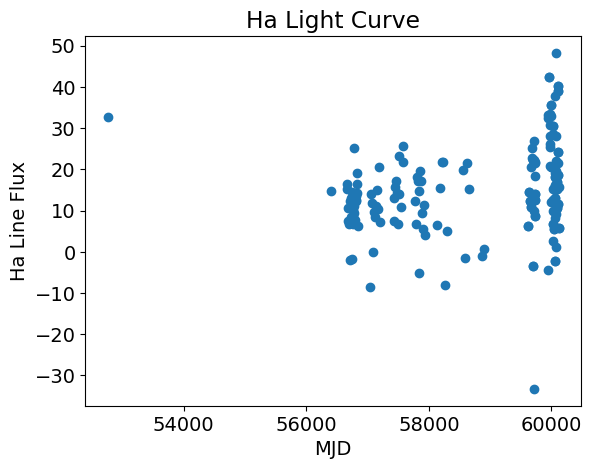

In [69]:
ha_times_jason = []
ha_values_jason = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f_line = line_flux(wl, fl, center_ha_jason, width=40)
    ha_times_jason.append(mjd)
    ha_values_jason.append(f_line)
plt.scatter(ha_times_jason, ha_values_jason)
plt.xlabel("MJD")
plt.ylabel("Ha Line Flux")
plt.title("Ha Light Curve")
plt.show();

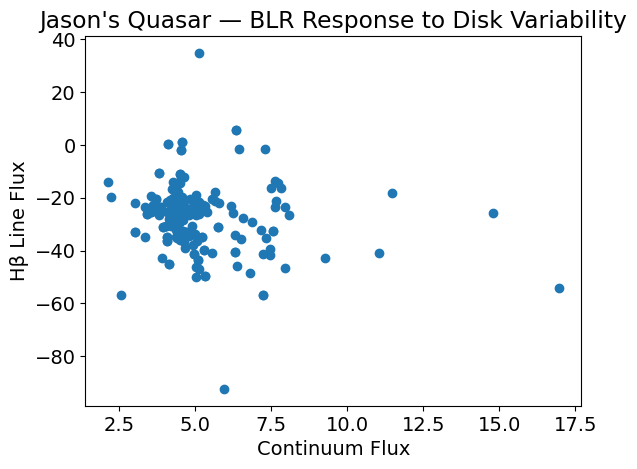

In [70]:
plt.scatter(cont_values_jason, hb_values_jason)
plt.xlabel("Continuum Flux")
plt.ylabel("Hβ Line Flux")
plt.title("Jason's Quasar — BLR Response to Disk Variability")
plt.show();

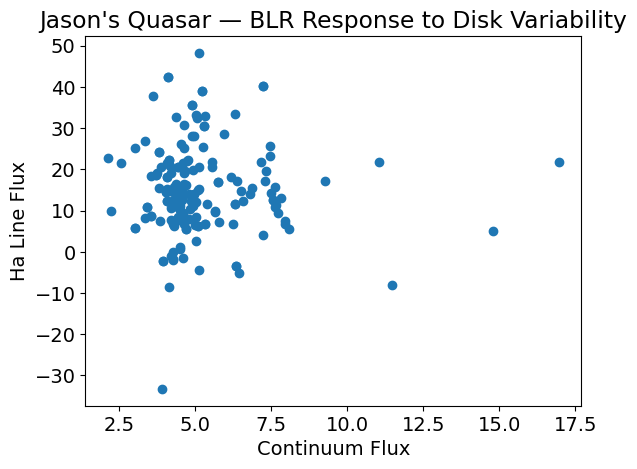

In [71]:
plt.scatter(cont_values_jason, ha_values_jason)
plt.xlabel("Continuum Flux")
plt.ylabel("Ha Line Flux")
plt.title("Jason's Quasar — BLR Response to Disk Variability")
plt.show();

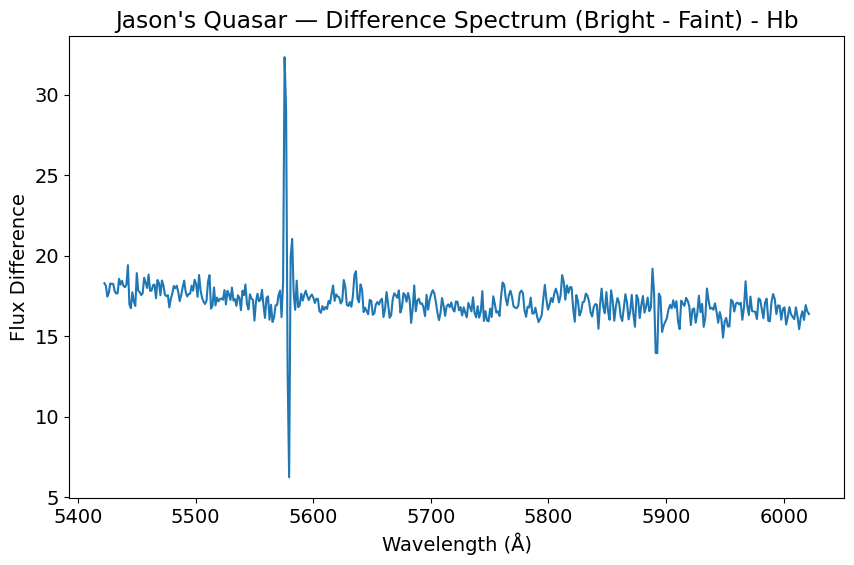

In [72]:
i_bright = np.argmax(cont_values_jason)
i_faint  = np.argmin(cont_values_jason)

wl_b = spectra[i_bright]["wavelength"]
fl_b = spectra[i_bright]["flux"]

wl_f = spectra[i_faint]["wavelength"]
fl_f = spectra[i_faint]["flux"]

fl_f_interp = np.interp(wl_b, wl_f, fl_f)

mask_diff = (wl_b > center_hb_jason - 300) & (wl_b < center_hb_jason + 300)

plt.figure(figsize=(10,6))
plt.plot(wl_b[mask_diff], fl_b[mask_diff] - fl_f_interp[mask_diff])
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux Difference")
plt.title("Jason's Quasar — Difference Spectrum (Bright - Faint) - Hb")
plt.show();

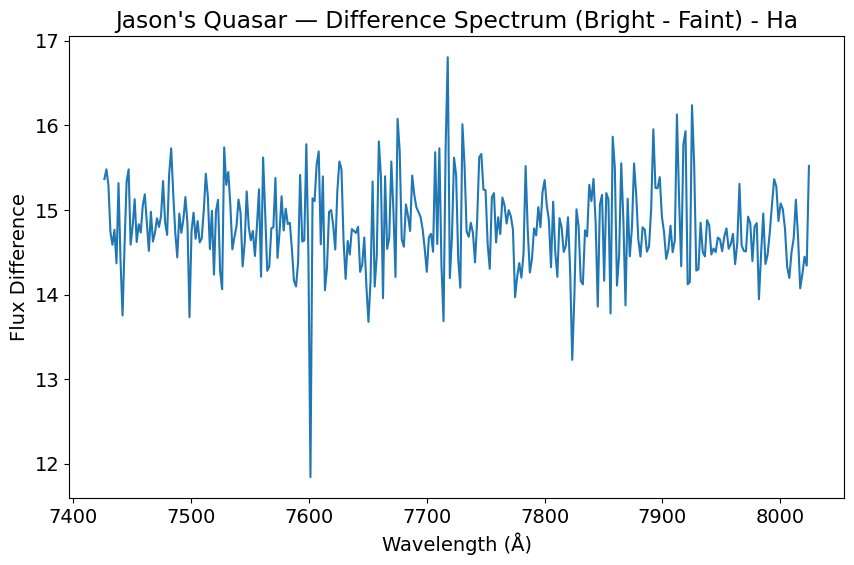

In [73]:
i_bright = np.argmax(cont_values_jason)
i_faint  = np.argmin(cont_values_jason)

wl_a = spectra[i_bright]["wavelength"]
fl_a = spectra[i_bright]["flux"]

wl_f = spectra[i_faint]["wavelength"]
fl_f = spectra[i_faint]["flux"]

fl_f_interp = np.interp(wl_a, wl_f, fl_f)

mask_diff = (wl_a > center_ha_jason - 300) & (wl_a < center_ha_jason + 300)

plt.figure(figsize=(10,6))
plt.plot(wl_a[mask_diff], fl_a[mask_diff] - fl_f_interp[mask_diff])
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux Difference")
plt.title("Jason's Quasar — Difference Spectrum (Bright - Faint) - Ha")
plt.show();

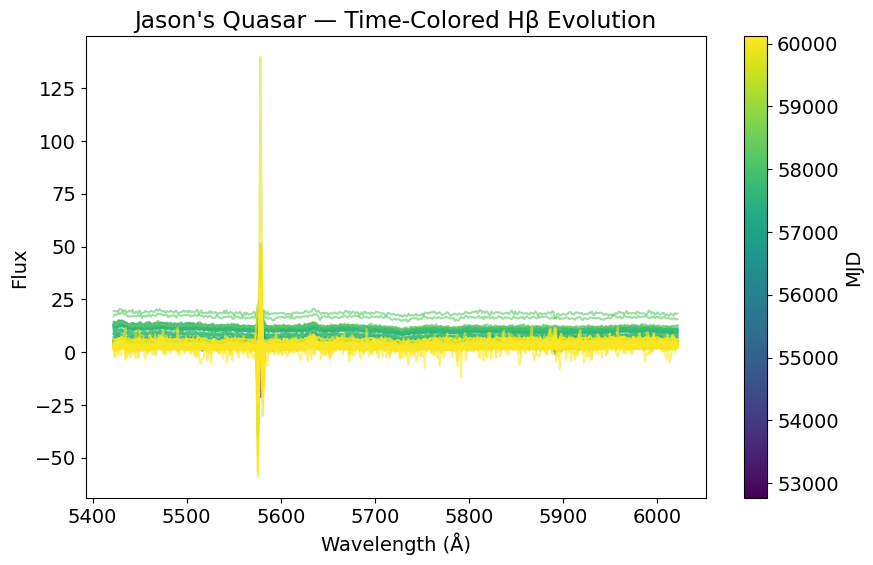

In [74]:
fig, ax = plt.subplots(figsize=(10,6))

mjds_jason = np.array([s["mjd"] for s in spectra])
norm = plt.Normalize(mjds_jason.min(), mjds_jason.max())
cmap = plt.cm.viridis

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mask_tc = (wl > center_hb_jason - 300) & (wl < center_hb_jason + 300)
    ax.plot(wl[mask_tc], fl[mask_tc], color=cmap(norm(s["mjd"])), alpha=0.6)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="MJD")

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Flux")
ax.set_title("Jason's Quasar — Time-Colored Hβ Evolution")
plt.show();

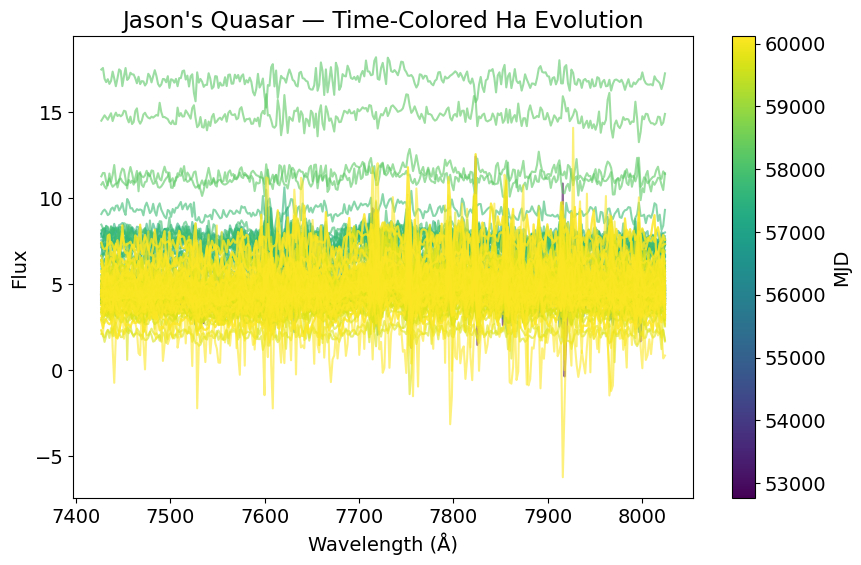

In [75]:
fig, ax = plt.subplots(figsize=(10,6))

mjds_jason = np.array([s["mjd"] for s in spectra])
norm = plt.Normalize(mjds_jason.min(), mjds_jason.max())
cmap = plt.cm.viridis

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mask_tc = (wl > center_ha_jason - 300) & (wl < center_ha_jason + 300)
    ax.plot(wl[mask_tc], fl[mask_tc], color=cmap(norm(s["mjd"])), alpha=0.6)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="MJD")

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Flux")
ax.set_title("Jason's Quasar — Time-Colored Ha Evolution")
plt.show();